# Organizacion de datos
---
## <center> Trabajo Práctico 1

### <center> Ejercicio 3 - Modelos de Regresión  

#### Grupo 05
| Integrante | Padron |
| :--- | :---: |
| Javier Zardain | 102521 |
| Bruno Pezman | 110457  |
| Malena Sein | 112295 |
| Candela Piccin | 109760 |
| Alexis Maximiliano Torres Vargas | 111449 |

**Dataset:** Airbnb listings - Copenhagen, Hovedstaden, Denmark - September 2025  

**Fuente:** Inside Airbnb

**Bibliografía:**
* Data dictionary: https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596

* Data source: https://data.insideairbnb.com/denmark/hovedstaden/copenhagen/2025-09-29/data/listings.csv.gz


# Objetivo

Se trabajará con datos de alojamientos de la plataforma AirBnB. El objetivo es predecir el
precio de alquiler (price) en función de la información publicada en los avisos mediante modelos de regresión.



## 1. Importación de librerías

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import ast
import joblib

## 2. Carga del dataset


In [115]:
#Descarga del dataset
#!gdown 1BQNi1nM4V1-Mg2ghwF2ZZdDWP2rFZjAq

In [116]:
#Carga desde filesystem
#df = pd.read_csv("listings.csv.gz")

#Descarga
url = 'https://data.insideairbnb.com/denmark/hovedstaden/copenhagen/2025-09-29/data/listings.csv.gz'
df = pd.read_csv(url, compression='gzip')

## Carga de modelos guardados en memoria (si se omite este paso reentrenará los modelos)

In [117]:
CARPETA_MODELOS = 'modelos'
os.makedirs(CARPETA_MODELOS, exist_ok=True)

USAR_MODELOS_CACHEADOS = len(os.listdir(CARPETA_MODELOS)) > 0

## 3. Análisis exploratorio y preprocesamiento:

In [118]:
print("Cantidad de columnas: ", df.shape[1])
print("Cantidad de filas:", df.shape[0])

Cantidad de columnas:  79
Cantidad de filas: 22994


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22994 entries, 0 to 22993
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22994 non-null  int64  
 1   listing_url                                   22994 non-null  object 
 2   scrape_id                                     22994 non-null  int64  
 3   last_scraped                                  22994 non-null  object 
 4   source                                        22994 non-null  object 
 5   name                                          22994 non-null  object 
 6   description                                   22457 non-null  object 
 7   neighborhood_overview                         7985 non-null   object 
 8   picture_url                                   22994 non-null  object 
 9   host_id                                       22994 non-null 

El análisis de los campos es el siguiente:
| Variable | Descripción | Tipo |
|---|---|---|
| id | Identificador único del alojamiento en Airbnb | Cuantitativa |
| listing_url | URL del alojamiento en Airbnb | Cualitativa |
| scrape_id | Identificador del proceso de extracción de datos | Cuantitativa |
| last_scraped | Fecha y hora en que se extrajo el dato | Cualitativa |
| source | Origen del listing: búsqueda por ciudad o scrape previo | Cualitativa |
| name | Nombre del alojamiento publicado por el host | Cualitativa |
| description | Descripción detallada del alojamiento | Cualitativa |
| neighborhood_overview | Descripción del barrio escrita por el host | Cualitativa |
| picture_url | URL de la imagen principal del alojamiento | Cualitativa |
| host_id | Identificador único del host en Airbnb | Cuantitativa |
| host_url | URL del perfil del host | Cualitativa |
| host_name | Nombre del host | Cualitativa |
| host_since | Fecha desde la que el host está registrado | Cualitativa |
| host_location | Ubicación autodeclarada por el host | Cualitativa |
| host_about | Descripción personal del host | Cualitativa |
| host_response_time | Tiempo típico de respuesta del host | Cualitativa |
| host_response_rate | Porcentaje de solicitudes a las que responde el host | Cuantitativa |
| host_acceptance_rate | Porcentaje de reservas que acepta el host | Cuantitativa |
| host_is_superhost | Indica si el host tiene distinción de Superhost | Cualitativa |
| host_thumbnail_url | URL de la foto miniatura del host | Cualitativa |
| host_picture_url | URL de la foto de perfil del host | Cualitativa |
| host_neighbourhood | Barrio declarado por el host | Cualitativa |
| host_listings_count | Cantidad de listings del host (cálculo interno de Airbnb) | Cuantitativa |
| host_total_listings_count | Total de listings del host (cálculo interno de Airbnb) | Cuantitativa |
| host_verifications | Métodos de verificación del host (email, teléfono, etc.) | Cualitativa |
| host_has_profile_pic | Indica si el host tiene foto de perfil | Cualitativa |
| host_identity_verified | Indica si la identidad del host fue verificada | Cualitativa |
| neighbourhood | Barrio declarado (sin limpiar) | Cualitativa |
| neighbourhood_cleansed | Barrio geocodificado a partir de coordenadas | Cualitativa |
| neighbourhood_group_cleansed | Grupo de barrio geocodificado a partir de coordenadas | Cualitativa |
| latitude | Latitud geográfica del alojamiento | Cuantitativa |
| longitude | Longitud geográfica del alojamiento | Cuantitativa |
| property_type | Tipo de propiedad autodeclarado por el host | Cualitativa |
| room_type | Tipo de habitación: alojamiento completo, privado o compartido | Cualitativa |
| accommodates | Capacidad máxima de huéspedes | Cuantitativa |
| bathrooms | Cantidad de baños (numérico) | Cuantitativa |
| bathrooms_text | Descripción textual de los baños | Cualitativa |
| bedrooms | Cantidad de dormitorios | Cuantitativa |
| beds | Cantidad de camas | Cuantitativa |
| amenities | Lista de comodidades ofrecidas | Cualitativa |
| price | Precio diario en moneda local (variable objetivo) | Cuantitativa |
| minimum_nights | Mínimo de noches requeridas por estadía | Cuantitativa |
| maximum_nights | Máximo de noches permitidas por estadía | Cuantitativa |
| minimum_minimum_nights | Menor valor mínimo de noches en el calendario futuro | Cuantitativa |
| maximum_minimum_nights | Mayor valor mínimo de noches en el calendario futuro | Cuantitativa |
| minimum_maximum_nights | Menor valor máximo de noches en el calendario futuro | Cuantitativa |
| maximum_maximum_nights | Mayor valor máximo de noches en el calendario futuro | Cuantitativa |
| minimum_nights_avg_ntm | Promedio del mínimo de noches en el calendario futuro | Cuantitativa |
| maximum_nights_avg_ntm | Promedio del máximo de noches en el calendario futuro | Cuantitativa |
| calendar_updated | Fecha de última actualización del calendario | Cualitativa |
| has_availability | Indica si el alojamiento tiene disponibilidad | Cualitativa |
| availability_30 | Días disponibles en los próximos 30 días | Cuantitativa |
| availability_60 | Días disponibles en los próximos 60 días | Cuantitativa |
| availability_90 | Días disponibles en los próximos 90 días | Cuantitativa |
| availability_365 | Días disponibles en los próximos 365 días | Cuantitativa |
| calendar_last_scraped | Fecha del último scraping del calendario | Cualitativa |
| number_of_reviews | Cantidad total de reseñas del alojamiento | Cuantitativa |
| number_of_reviews_ltm | Reseñas recibidas en los últimos 12 meses | Cuantitativa |
| number_of_reviews_l30d | Reseñas recibidas en los últimos 30 días | Cuantitativa |
| first_review | Fecha de la primera reseña | Cualitativa |
| last_review | Fecha de la última reseña | Cualitativa |
| review_scores_rating | Puntuación general del alojamiento | Cuantitativa |
| review_scores_accuracy | Puntuación de exactitud de la descripción | Cuantitativa |
| review_scores_cleanliness | Puntuación de limpieza | Cuantitativa |
| review_scores_checkin | Puntuación del proceso de check-in | Cuantitativa |
| review_scores_communication | Puntuación de comunicación con el host | Cuantitativa |
| review_scores_location | Puntuación de la ubicación | Cuantitativa |
| review_scores_value | Puntuación de la relación precio-calidad | Cuantitativa |
| license | Número de licencia o permiso del alojamiento | Cualitativa |
| instant_bookable | Indica si se puede reservar sin aprobación previa del host | Cualitativa |
| calculated_host_listings_count | Cantidad de listings del host en la ciudad (Inside Airbnb) | Cuantitativa |
| calculated_host_listings_count_entire_homes | Listings completos del host en la ciudad | Cuantitativa |
| calculated_host_listings_count_private_rooms | Habitaciones privadas del host en la ciudad | Cuantitativa |
| calculated_host_listings_count_shared_rooms | Habitaciones compartidas del host en la ciudad | Cuantitativa |
| reviews_per_month | Promedio de reseñas por mes durante la vida del listing | Cuantitativa |

# Limpieza preliminar

Este dataset tiene una cantidad muy grande de columnas, para mejorar los resultados de la regresión es necesario hacer un análisis de cuales de estas aportan realmente información para el objetivo de calcular el precio.

# Valores nulos

Una de las primeras cosas que hemos notado es que hay una cantidad muy grande de registros sin "price" que es nuestra variable objetivo, sin esa variable esos registros no nos sirven, por lo que podemos quitarlos. Observamos consecuentemente que esos registros tampoco tienen "estimated_revenue_l365d" que se deriva del precio, por lo que la reconstrucción del precio es imposible.

In [120]:
df.query("price.isna()")["estimated_revenue_l365d"].notna().sum()

np.int64(0)

In [121]:
#Quito los registros sin price
df = df.dropna(subset=['price'])

Se observa que las columnas "neighbourhood_group_cleansed", "calendar_updated" y "license" solo tienen valores no nulos, por lo tanto pueden eliminarse.

In [122]:
df = df.drop(columns=["neighbourhood_group_cleansed", "calendar_updated", "license"])

Veamos que porcentaje de valores nulos quedan en las demás columnas:

In [123]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
host_neighbourhood,83.380449
neighborhood_overview,70.882309
neighbourhood,70.882309
host_about,58.659426
host_location,19.766404
...,...
instant_bookable,0.000000
calculated_host_listings_count,0.000000
calculated_host_listings_count_entire_homes,0.000000
calculated_host_listings_count_private_rooms,0.000000


Las columnas host_neighbourhood y neighbourhood tienen una proporción de registros nulos muy elevados, por lo tanto vamos a eliminar estas columnas también.

In [124]:
df = df.drop(columns=["host_neighbourhood", "neighbourhood"])

Observaremos algunos de los elementos para determinar que tipo de información se trata y que estrategia adoptar para completar los datos faltantes.

In [125]:
df.iloc[0].to_frame()

,0
id,23500
listing_url,https://www.airbnb.com/rooms/23500
scrape_id,20250929042231
last_scraped,2025-09-29
source,city scrape
...,...
calculated_host_listings_count,2
calculated_host_listings_count_entire_homes,1
calculated_host_listings_count_private_rooms,1
calculated_host_listings_count_shared_rooms,0


Se puede apreciar a simple vista que aparecen más columnas candidatas a eliminarse ya que no resultan útiles para el objetivo de predecir el precio de una propiedad y solo agregan ruido, estas son:
1) IDs únicos: id, host_id, scrape_id
2) Urls: listing_url, host_url, host_thumbnail_url, host_picture_url
3) Datos relacionados al scraping: last_scraped, calendar_last_scraped, source
4) Campos de texto libre, tienen información poco útil o sesgada por haber sido escritas por el arrendatario: name, description, host_about, neighborhood_overview, host_location, host_name, bathrooms_text.

In [126]:
#df = df.drop(columns=["id", "host_id", "scrape_id", "listing_url", "picture_url", "host_url", "host_thumbnail_url", "host_picture_url", "last_scraped", "calendar_last_scraped", "source", "name", "description", "host_about", "neighborhood_overview", "host_location", "host_name", "bathrooms_text"])
df = df.drop(columns=["id", "host_id", "scrape_id", "listing_url", "host_url", "host_thumbnail_url", "host_picture_url", "last_scraped", "calendar_last_scraped", "source", "name", "description", "host_about", "neighborhood_overview", "host_location", "host_name", "bathrooms_text"])

# Valores únicos

Veo si queda alguna columna con valores únicos que no aporten nada al modelo:

In [127]:
df.columns[df.nunique() == 1]

Index(['has_availability'], dtype='object')

La columna has availability tiene casi exclusivamente el valor "true", lo que aporta poca información. Vamos a ver cuantos valores null hay (que podrían representar un "false")

In [128]:
df['has_availability'].value_counts(dropna=False)



,count
has_availability,
t,13264
NaN,178


La cantidad es muy pequeña, alrededor del 2%, decidimos quitar esta columna ya que no va a aportar nada al modelo.

In [129]:
df = df.drop(columns=["has_availability"])

Busco más columnas con muy poca variabilidad

In [130]:
for col in df.select_dtypes(include='object').columns:
    top_val = df[col].value_counts(normalize=True).iloc[0] * 100
    if(top_val > 95):
        print(f"{col}: {top_val:.1f}%")

host_has_profile_pic: 95.6%


El campo "host_has_profile_pic" tiene muy poca variabilidad así que también la quitamos.

In [131]:
df = df.drop(columns=["host_has_profile_pic"])

# Correlacion de variables

Busco columnas con una alta correlación para evaluar si puedo quedarme con solo uno de ellas

In [132]:
corr = df.select_dtypes(include='number').corr()
corr_pairs = (corr.abs()
               .unstack()
               .sort_values(ascending=False)
               .drop_duplicates())

corr_pairs[corr_pairs > 0.8].drop(index=corr_pairs[corr_pairs == 1].index)

,,0
availability_eoy,availability_90,0.999099
calculated_host_listings_count,calculated_host_listings_count_entire_homes,0.999061
maximum_maximum_nights,maximum_nights_avg_ntm,0.998055
maximum_nights_avg_ntm,minimum_maximum_nights,0.995677
maximum_maximum_nights,minimum_maximum_nights,0.990624
availability_60,availability_90,0.971488
availability_eoy,availability_60,0.967134
maximum_minimum_nights,minimum_nights_avg_ntm,0.965810
minimum_nights,minimum_nights_avg_ntm,0.953690
host_total_listings_count,host_listings_count,0.944793


Vemos que hay campos que tienen una correlación extremadamente alta, por lo que vamos a quedarnos solo con uno de ellos:
- **availability_eoy | availability_365 | availability_90 | availability_60 | availability_30**: Nos quedaremos con availability_365 que es la más completa.

- **calculated_host_listings_count |calculated_host_listings_count_entire_homes | calculated_host_listings_count_private_rooms | calculated_host_listings_count_shared_rooms**: nos quedaremos calculated_host_listings_count ya que la otra información se deriva de esa variable + room_type.

- **host_total_listings_count | host_listings_count | calculated_host_listings_count**: Nos quedaremos con calculated_host_listings_count que es más confiable porque es calculada por AirBnb y no por el host.

- **minimum_nights | maximum_nights | minimum_minimum_nights | maximum_minimum_nights | minimum_maximum_nights | maximum_maximum_nights | minimum_nights_avg_ntm | maximum_nights_avg_ntm**: Nos quedaremos solo con minimum_nights y maximum_nights ya que las demás miden lo mismo con diferentes criterios.

- **reviews_per_month | number_of_reviews_ltm | number_of_reviews_ly** **| number_of_reviews_l30d**: Nos quedaremos solo con reviews_per_month registra mejor la popularidad la vigencia de la popularidad del lugar.

In [133]:
df = df.drop(columns=["availability_eoy", "availability_90", "availability_60", "availability_30","host_total_listings_count","host_listings_count", "calculated_host_listings_count_entire_homes","calculated_host_listings_count_private_rooms","calculated_host_listings_count_shared_rooms", "minimum_minimum_nights", "maximum_minimum_nights","minimum_maximum_nights","maximum_maximum_nights", "minimum_nights_avg_ntm","maximum_nights_avg_ntm", "number_of_reviews_ltm", "number_of_reviews_ly", "number_of_reviews_l30d" ])

Otras variables que tienen una alta correlación son las referidas al desagregado de las reviews:

In [134]:
review_cols = [col for col in df.columns if 'review_scores' in col]
df[review_cols].corr()

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
review_scores_rating,1.000000,0.785388,0.735957,0.581931,0.695576,0.474346,0.745252
review_scores_accuracy,0.785388,1.000000,0.641479,0.503647,0.618509,0.442321,0.687553
review_scores_cleanliness,0.735957,0.641479,1.000000,0.440507,0.494156,0.367711,0.643070
review_scores_checkin,0.581931,0.503647,0.440507,1.000000,0.631386,0.349073,0.478734
review_scores_communication,0.695576,0.618509,0.494156,0.631386,1.000000,0.356179,0.557340
review_scores_location,0.474346,0.442321,0.367711,0.349073,0.356179,1.000000,0.462696
review_scores_value,0.745252,0.687553,0.643070,0.478734,0.557340,0.462696,1.000000


Por lo tanto mantendremos solo "review_scores_rating" que representa a la calificación general:

In [135]:
df = df.drop(columns=[
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
])

Hay una variable problemática y es "estimated_revenue_l365d", esta variable no está en el data dictionary, pero se podría inferir que puede ser el precio por la cantidad de noches rentadas, vamos a corroborarlo:

In [136]:
dfPrueba = df.copy()
dfPrueba['price'] = dfPrueba['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float).astype(int)
dfPrueba['revenue_check'] = dfPrueba['price'] * dfPrueba['estimated_occupancy_l365d']
dfPrueba[['estimated_revenue_l365d', 'revenue_check']].corr()

,estimated_revenue_l365d,revenue_check
estimated_revenue_l365d,1.0,1.0
revenue_check,1.0,1.0


Como la correlación es 1, debemos quitar esta variable ya que le indicaría indirectamente al modelo el valor del precio y haría que el entrenamiento sea inútil.

In [137]:
df = df.drop(columns=["estimated_revenue_l365d"])

# Transformación de variables

Habiendo ya abordado el problema de las columnas a retirar, se transformarán las variables a valores más convenientes para la regresión.

Fechas: calcularemos días desde las fechas citadas para que sean más útiles como dato.

In [138]:
hoy = pd.to_datetime('2025-09-29')

df['host_age_days'] = (hoy - pd.to_datetime(df['host_since'])).dt.days
df['days_since_first_review'] = (hoy - pd.to_datetime(df['first_review'])).dt.days
df['days_since_last_review'] = (hoy - pd.to_datetime(df['last_review'])).dt.days

df = df.drop(columns=['host_since', 'first_review', 'last_review'])

Analizo las amenities para poder convertirlas en categorías (ej: wifi, estacionamiento, etc)

In [139]:
import re

def categorizar_amenities(amenities_list):
    """Recibe una lista de amenities y devuelve un dict con las categorías detectadas."""
    cats = set()

    for amenity in amenities_list:
        a = amenity.lower()

        # 1. PRIVATE OUTDOOR (23%)
        if any(x in a for x in ['private patio', 'private balcony', 'private entrance',
                                 'private backyard']):
            cats.add('private_outdoor')

        # 2. ELEVATOR (13%)
        if a == 'elevator':
            cats.add('has_elevator')

        # 3. FREE PARKING (14%)
        if any(x in a for x in ['free parking', 'free driveway', 'free carport',
                                 'free residential garage', 'free street parking']):
            cats.add('free_parking')

        # 4. PAID PARKING (35%)
        if 'paid parking' in a or 'paid street parking' in a or 'paid valet' in a:
            cats.add('paid_parking')

        # 5. DISHWASHER (55%)
        if a == 'dishwasher':
            cats.add('has_dishwasher')

        # 6. WORKSPACE (42%)
        if 'dedicated workspace' in a:
            cats.add('has_workspace')

        # 7. SELF CHECK-IN (34%)
        if any(x in a for x in ['self check-in', 'lockbox', 'keypad', 'smart lock']):
            cats.add('self_checkin')

        # 8. OUTDOOR DINING (47%)
        if 'outdoor dining' in a or 'outdoor furniture' in a:
            cats.add('outdoor_dining')

        # 9. WATER ACCESS (12%)
        if any(x in a for x in ['lake access', 'beach access', 'shared beach',
                                 'beachfront', 'boat slip', 'kayak']):
            cats.add('water_access')
            if 'beachfront' in a:
                cats.add('beachfront')

        # 10. VIEWS - separadas por tipo
        if a == 'waterfront':
            cats.add('water_view')
        if any(x in a for x in ['ocean view', 'sea view', 'harbor view', 'harbour view',
                                 'marina view', 'canal view', 'lake view', 'river view',
                                 'bay view', 'beach view']):
            cats.add('water_view')
        if any(x in a for x in ['city skyline view', 'park view']):
            cats.add('city_view')
        if any(x in a for x in ['garden view', 'courtyard view']):
            cats.add('garden_view')
        if 'pool view' in a or 'golf course view' in a or 'resort view' in a:
            cats.add('has_view_other')

        # 11. PREMIUM COFFEE (5-4%)
        if 'espresso' in a or 'nespresso' in a:
            cats.add('premium_coffee')

        # 12. KID FRIENDLY (11%)
        if any(x in a for x in ["children's", 'crib', 'high chair', 'baby bath',
                                 'baby safety', 'baby monitor', 'babysitter',
                                 'changing table', "pack 'n play", 'outlet covers',
                                 'window guards', 'table corner guards']):
            cats.add('kid_friendly')

        # 13. PETS (11%)
        if a == 'pets allowed':
            cats.add('pets_allowed')

        # 14. AIR CONDITIONING (1.8% - raro en Copenhagen)
        if any(x in a for x in ['air conditioning', 'central air conditioning',
                                 'portable air conditioning', 'window ac',
                                 'split type ductless']):
            cats.add('has_ac')

        # 15. BATHTUB (6.7%)
        if a == 'bathtub':
            cats.add('has_bathtub')

        # 16. PREMIUM SOUND - Sonos/B&O y marcas premium danesas
        if any(x in a for x in ['sonos', 'b&o', 'bang & olufsen', 'bang&olufsen',
                                 'beoplay', 'beosound', 'beolit', 'bang og olufsen',
                                 'bang and olufsen', 'bang olufsen', 'b og o',
                                 'bang  & olufsen', 'bang & olufens', 'bang og olufsen',
                                 'naim', 'devialet', 'b & o']):
            cats.add('premium_sound')

        # 17. PREMIUM KITCHEN BRANDS
        if any(x in a for x in ['gaggenau', 'miele', 'smeg', 'kitchenaid', 'kitchen aid',
                                 'ilve', 'bertazzoni', 'wolf induction', 'bora induction',
                                 'bora stove', 'bora x bo']):
            cats.add('premium_kitchen')

        # 18. FIREPLACE (3.3%)
        if 'indoor fireplace' in a:
            cats.add('has_fireplace')

        # 19. BBQ (21%)
        if 'bbq grill' in a or 'barbecue' in a:
            cats.add('has_bbq')
            if 'private' in a:
                cats.add('private_bbq')

        # 20. LONG TERM (16%)
        if 'long term stays' in a:
            cats.add('long_term_allowed')

        # 21. LAUNDRY IN UNIT (12%)
        if ('washer' in a or 'dryer' in a) and 'in unit' in a and 'hair dryer' not in a:
            cats.add('laundry_in_unit')

        # 22. GYM (3.4%)
        if 'gym' in a or 'exercise equipment' in a:
            cats.add('has_gym')

        # 23. ENTERTAINMENT
        if a == 'piano':
            cats.add('has_piano')
        if 'game console' in a:
            cats.add('has_game_console')
        if any(x in a for x in ['pool table', 'ping pong', 'arcade', 'bowling',
                                 'movie theater', 'hockey rink', 'mini golf',
                                 'climbing wall', 'skate ramp', 'batting cage',
                                 'laser tag', 'life size games']):
            cats.add('has_recreation')

        # 24. EV CHARGER (5.2%)
        if 'ev charger' in a:
            cats.add('has_ev_charger')

        # 25. HOUSEKEEPING (4.5%)
        if 'cleaning available' in a or 'housekeeping' in a:
            cats.add('has_housekeeping')

        # 26. HOT TUB (0.3%)
        if 'hot tub' in a:
            cats.add('has_hot_tub')

        # 27. SAUNA (0.1%)
        if 'sauna' in a:
            cats.add('has_sauna')

        # 28. POOL (0.2%)
        if ('pool' in a and 'pool table' not in a and 'pool view' not in a
            and 'pool toys' not in a):
            cats.add('has_pool')

        # 29. DARKENING SHADES (35%)
        if 'room-darkening' in a:
            cats.add('darkening_shades')

        # 30. BIKES (2.6%)
        if a in ['bikes', "children's bikes"]:
            cats.add('has_bikes')

        # 31. SMOKING (1.8%)
        if a == 'smoking allowed':
            cats.add('smoking_allowed')

        # 32. BREAKFAST (0.5%)
        if a == 'breakfast':
            cats.add('has_breakfast')

        # 33. PREMIUM TOILETRIES (<1%)
        if any(x in a for x in ['aesop', 'rituals', 'l:a bruket', 'acqua di parma',
                                 'kevin murphy', 'kerastase', 'keratase', 'frama',
                                 'tromborg', 'skandinavisk', 'meraki', 'rudolph care',
                                 'marie stella', 'korres']):
            cats.add('premium_toiletries')

        # 34. ETHERNET (8%)
        if 'ethernet' in a or 'pocket wifi' in a:
            cats.add('has_ethernet')

        # 35. LARGE TV 55"+ (~5%)
        size_match = re.match(r'(\d+)\s*inch', a)
        if size_match and int(size_match.group(1)) >= 55:
            cats.add('large_tv')

        # 36. STREAMING (~5%)
        if any(x in a for x in ['netflix', 'hbo max', 'disney+', 'amazon prime',
                                 'hulu', 'apple tv']):
            cats.add('has_streaming')

    return cats

# Aplicar
all_categories = set()
parsed = df['amenities'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
categorized = parsed.apply(categorizar_amenities)

# Recolectar todas las categorías que aparecen
for cats in categorized:
    all_categories.update(cats)

all_categories = sorted(all_categories)
print(f"Categorías generadas: {len(all_categories)}")

# Crear columnas binarias
for cat in all_categories:
    df[cat] = categorized.apply(lambda x: 1 if cat in x else 0)

# Conservar también el conteo total
df['amenities_count'] = parsed.apply(len)

# Mostrar frecuencias
print(f"\n{'Categoría':<25s} {'Count':>6s} {'%':>6s}")
print("-" * 40)
for cat in all_categories:
    n = df[cat].sum()
    pct = n / len(df) * 100
    print(f"{cat:<25s} {n:>6d} {pct:>5.1f}%")

# Eliminar columna original
df = df.drop(columns=['amenities'])

Categorías generadas: 43

Categoría                  Count      %
----------------------------------------
beachfront                    78   0.6%
city_view                    770   5.7%
darkening_shades            4735  35.2%
free_parking                2443  18.2%
garden_view                 1403  10.4%
has_ac                       339   2.5%
has_bathtub                  903   6.7%
has_bbq                     3388  25.2%
has_bikes                    350   2.6%
has_breakfast                 63   0.5%
has_dishwasher              7324  54.5%
has_elevator                1721  12.8%
has_ethernet                1150   8.6%
has_ev_charger               812   6.0%
has_fireplace                573   4.3%
has_game_console             500   3.7%
has_gym                      854   6.4%
has_hot_tub                   75   0.6%
has_housekeeping             832   6.2%
has_piano                    700   5.2%
has_pool                      69   0.5%
has_recreation               401   3.0%
has_sauna    

Hago un conteo de host_verifications

In [140]:
df['verifications_count'] = df['host_verifications'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
df = df.drop(columns=['host_verifications'])

Convierto price a un valor numérico:

In [141]:
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

Convierto los valores booleanos a 1/0:

In [142]:
bool_cols = ['host_is_superhost', 'host_identity_verified', 'instant_bookable']
for col in bool_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

Convertimos a numéricos otros campos:

In [143]:
df['host_response_rate'] = df['host_response_rate'].str.replace('%', '').astype(float)
df['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%', '').astype(float)

Convertimos host_response_time a ordinal:

In [144]:
response_order = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}
df['host_response_time'] = df['host_response_time'].map(response_order)

# Análisis de imagen del AirBnb

Un campo interesante que podría merecer la pena conservar son las imágenes del AirBnb. Se tomará una muestra de 500 fotos y se analizará si hay alguna correlación con el precio, de ser así, se procesarán todos los registros restantes.

In [145]:
import requests
from pathlib import Path

sample = df.sample(500, random_state=42)

if USAR_MODELOS_CACHEADOS:
    print("Scores de CLIP ya cacheados → se omite descarga de imágenes")
    scores = {}
else:
    img_dir = Path('images')
    img_dir.mkdir(exist_ok=True)

    scores = {}
    errores = 0

    for idx, row in sample.iterrows():
        url = row['picture_url']
        path = img_dir / f"{idx}.jpg"
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200:
                path.write_bytes(r.content)
                scores[idx] = str(path)
            else:
                errores += 1
        except:
            errores += 1

    print(f"Descargadas: {len(scores)}, Errores: {errores}")

Scores de CLIP ya cacheados → se omite descarga de imágenes


Utilizaremos el modelo CLIP para asignarle un puntaje a la imagen dependiendo de su atractivo general

In [146]:
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import torch

if USAR_MODELOS_CACHEADOS:
    image_scores = joblib.load('modelos/clip_image_scores.joblib')
    print(f"Scores de CLIP cargados: {len(image_scores)} imágenes")
else:
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    texts = [
        "a beautiful, bright, modern, well-decorated apartment with great lighting",
        "a dark, ugly, messy, poorly maintained room"
    ]

    image_scores = {}
    for idx, path in scores.items():
        try:
            image = Image.open(path).convert("RGB")
            inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits_per_image.softmax(dim=1)
                image_scores[idx] = logits[0][0].item()
        except:
            pass

    joblib.dump(image_scores, 'modelos/clip_image_scores.joblib')
    print(f"Imágenes puntuadas y guardadas: {len(image_scores)}")

Scores de CLIP cargados: 479 imágenes


Graficar la correlación con el precio, si está muy lejos de 1 borramos el campo:

Correlación image_score vs price: 0.093


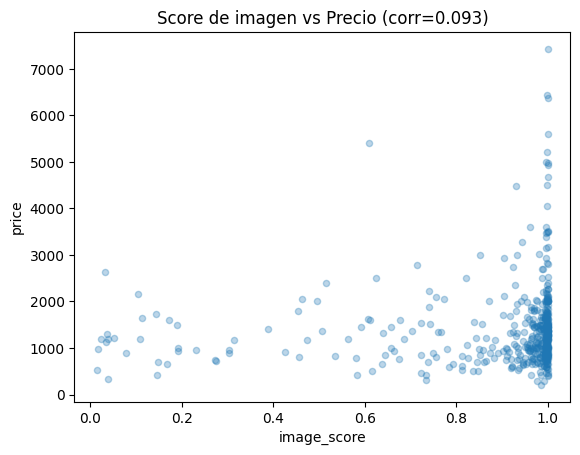

In [147]:
# 3. Ver si correlaciona con el precio
score_df = pd.DataFrame({
    'price': sample.loc[image_scores.keys(), 'price'],
    'image_score': pd.Series(image_scores)
})

corr = score_df['image_score'].corr(score_df['price'])
print(f"Correlación image_score vs price: {corr:.3f}")

# Si es > 0.1, vale la pena escalar a los 15.000
# Si es < 0.05, no va a mover la aguja

score_df.plot.scatter(x='image_score', y='price', alpha=0.3)
plt.title(f'Score de imagen vs Precio (corr={corr:.3f})')
plt.show()

Como la correlación es bajísima 0.093, podemos borrar la url de la foto

In [148]:
df = df.drop(columns=["picture_url"])

# Imputación de valores nulos

Ahora se completarán los registros nulos restantes mediante diferentes técnicas dependiendo del dato

Para estos casos con pocos nulos, se imputará con la mediana:

In [149]:
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds'] = df['beds'].fillna(df['beds'].median())
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].median())
df['host_age_days'] = df['host_age_days'].fillna(df['host_age_days'].median())

Para los casos de listings sin reseñas colocaremos 0

In [150]:
review_cols = [
    'review_scores_rating', 'reviews_per_month', 'days_since_first_review','days_since_last_review'
]
df[review_cols] = df[review_cols].fillna(0)

Para los indicadores de la respuesta del host colocaremos 0 en el rate de respuesta y 5 días en tiempo de respuesta.

In [151]:
df['host_response_rate'] = df['host_response_rate'].fillna(0)
df['host_response_time'] = df['host_response_time'].fillna(5)

Para las variables booleanas imputaremos la moda:

In [152]:
df['host_is_superhost'] = df['host_is_superhost'].fillna(df['host_is_superhost'].mode()[0])
df['host_identity_verified'] = df['host_identity_verified'].fillna(df['host_identity_verified'].mode()[0])

# Outliers

In [153]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
host_response_time,13442.0,2.560408,1.392890,1.0,1.0,2.0,3.0,5.0
host_response_rate,13442.0,72.351510,39.888103,0.0,50.0,100.0,100.0,100.0
host_acceptance_rate,13442.0,62.012573,33.070172,0.0,36.0,67.0,95.0,100.0
host_is_superhost,13442.0,0.152433,0.359453,0.0,0.0,0.0,0.0,1.0
host_identity_verified,13442.0,0.902172,0.297093,0.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...
smoking_allowed,13442.0,0.018003,0.132968,0.0,0.0,0.0,0.0,1.0
water_access,13442.0,0.165972,0.372070,0.0,0.0,0.0,0.0,1.0
water_view,13442.0,0.061970,0.241110,0.0,0.0,0.0,0.0,1.0
amenities_count,13442.0,27.378887,15.008872,0.0,15.0,27.0,38.0,106.0


Vemos varios campos con outliers bastante graves, particularmente el precio que tiene un valor extremadamente alto.
Vamos a revisar los outliers con varios gráficos.

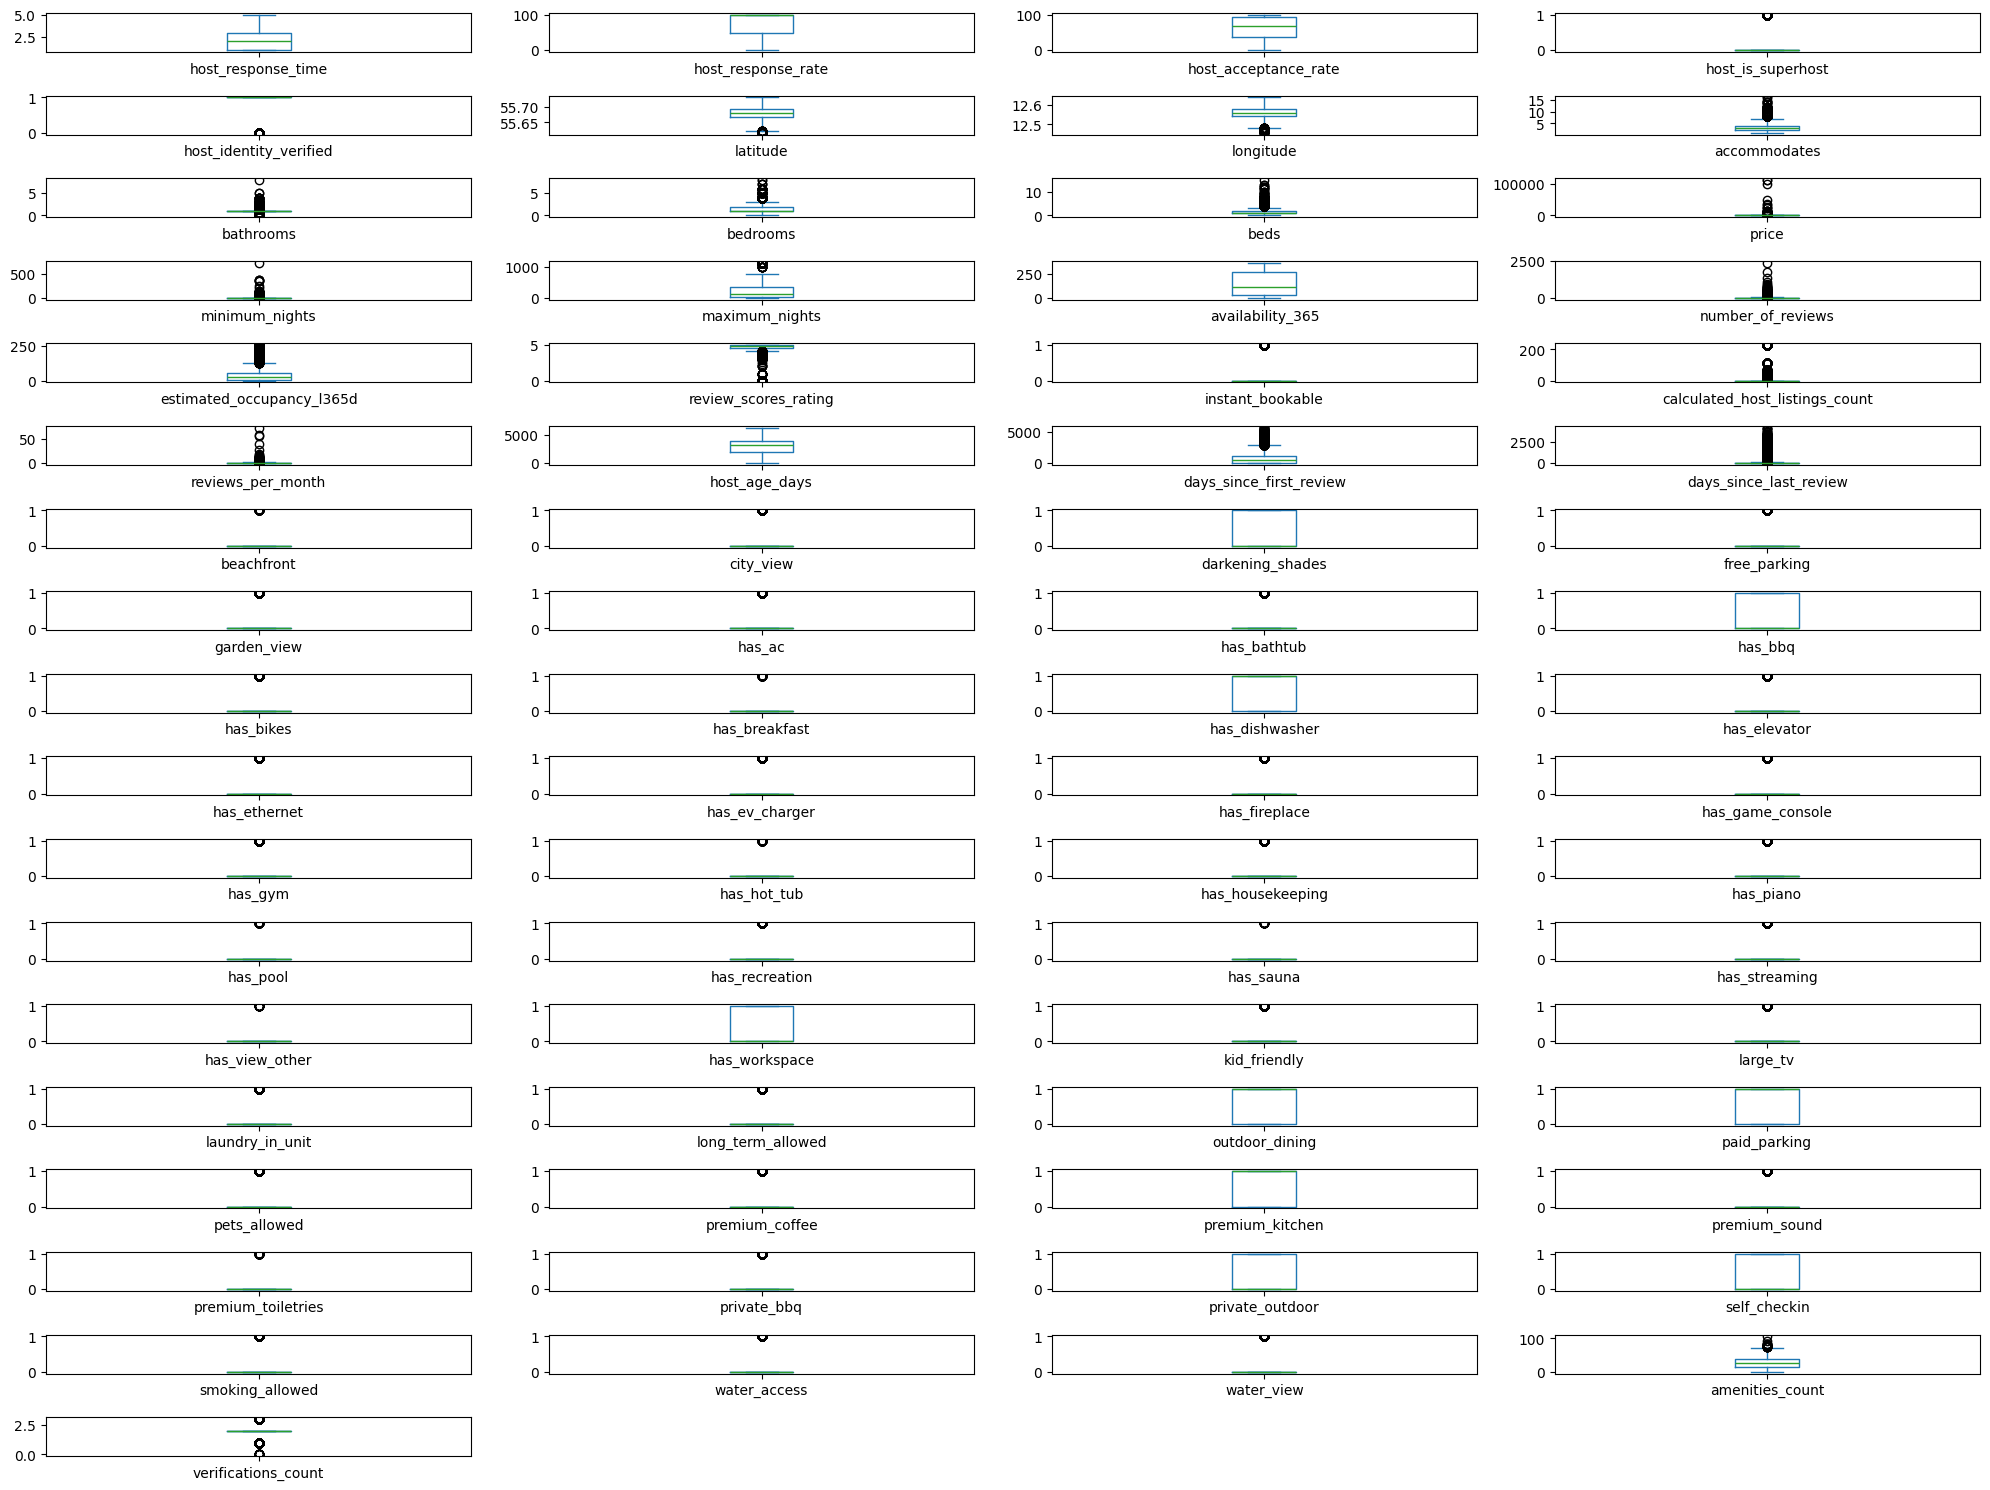

In [154]:
cols_numericas = df.select_dtypes(include='number').columns
df[cols_numericas].plot(kind='box', subplots=True, figsize=(20, 15), layout=(-1, 4))
plt.tight_layout()
plt.show()

Vamos a aplicar el z-score y hacer dos diagramas para cada columna, uno con los outliers y otro sin los outliers.

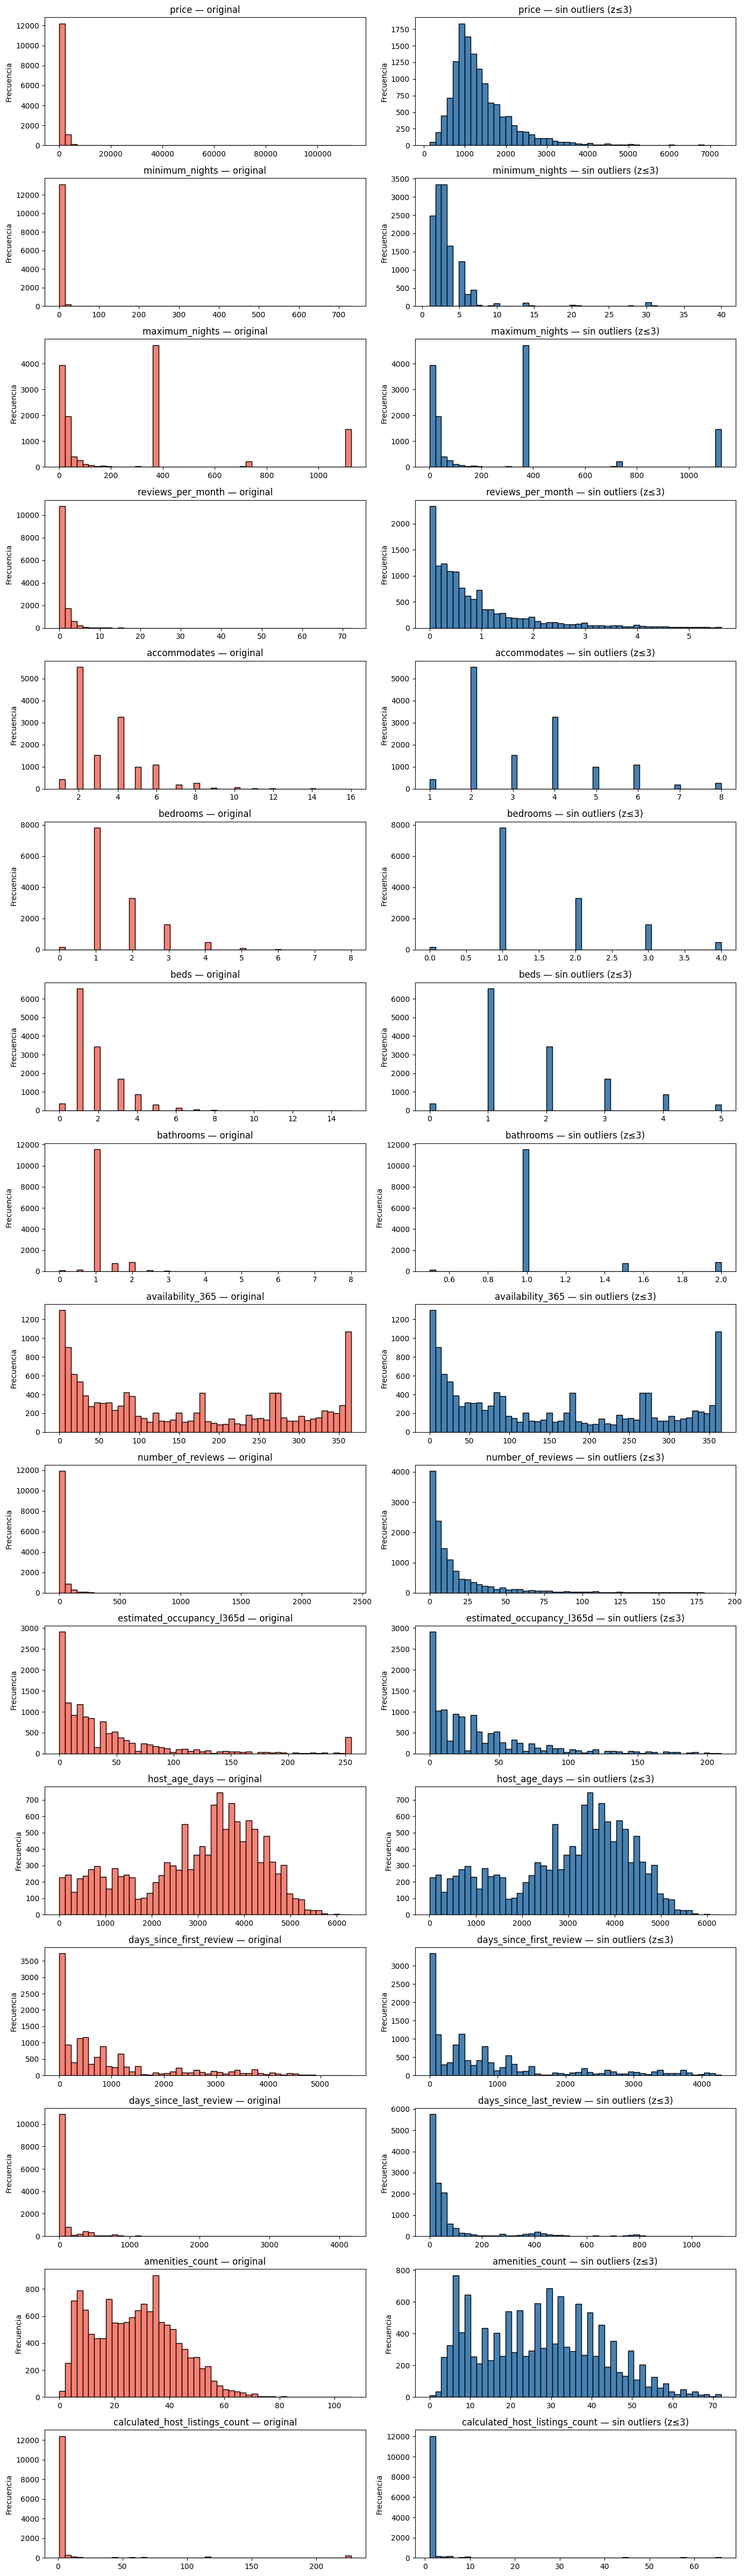

In [155]:
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

cols_continuas = [
    'price', 'minimum_nights', 'maximum_nights', 'reviews_per_month',
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'availability_365', 'number_of_reviews', 'estimated_occupancy_l365d',
    'host_age_days', 'days_since_first_review', 'days_since_last_review',
    'amenities_count', 'calculated_host_listings_count'
]

def z_calculation(serie):
    media = np.mean(serie)
    std = np.std(serie)
    return (serie - media) / std

#Usamos 3 que es lo usual como umbral para una serie normal
umbral = 3
n_cols = len(cols_continuas)
fig, axes = plt.subplots(n_cols, 2, figsize=(14, n_cols * 3))

for i, col in enumerate(cols_continuas):
    serie = df[col]
    serie_z = z_calculation(serie)
    serie_limpia = serie[np.abs(serie_z) <= umbral]

    # Histograma original
    axes[i, 0].hist(serie, bins=50, color='salmon', edgecolor='black')
    axes[i, 0].set_title(f'{col} — original')
    axes[i, 0].set_ylabel('Frecuencia')

    # Histograma sin outliers
    axes[i, 1].hist(serie_limpia, bins=50, color='steelblue', edgecolor='black')
    axes[i, 1].set_title(f'{col} — sin outliers (z≤{umbral})')
    axes[i, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Vamos a calcular cuantos registros perderíamos al limpiar los outliers para cada columna:

In [156]:
df_temp = df.copy()
cols_continuas = [
    'price', 'minimum_nights', 'reviews_per_month',
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'availability_365', 'number_of_reviews',
    'estimated_occupancy_l365d', 'host_age_days',
    'days_since_first_review', 'days_since_last_review',
    'amenities_count', 'calculated_host_listings_count'
]
for col in cols_continuas:
    z = z_calculation(df_temp[col])
    antes = len(df_temp)
    df_temp = df_temp[np.abs(z) <= umbral]
    despues = len(df_temp)
    print(f"{col}: -{antes - despues} filas ({(antes-despues)/antes*100:.1f}%)")

print(f"\nTotal final: {len(df_temp)} filas")

price: -45 filas (0.3%)
minimum_nights: -78 filas (0.6%)
reviews_per_month: -139 filas (1.0%)
accommodates: -123 filas (0.9%)
bedrooms: -57 filas (0.4%)
beds: -149 filas (1.1%)
bathrooms: -152 filas (1.2%)
availability_365: -0 filas (0.0%)
number_of_reviews: -238 filas (1.9%)
estimated_occupancy_l365d: -350 filas (2.8%)
host_age_days: -0 filas (0.0%)
days_since_first_review: -194 filas (1.6%)
days_since_last_review: -231 filas (1.9%)
amenities_count: -18 filas (0.2%)
calculated_host_listings_count: -313 filas (2.7%)

Total final: 11355 filas


Tras analizar quitaremos solo los outliers del precio ya que es la variable con mayor importancia en el entrenamiento y que implica sacrificar menor cantidad de registros.

In [157]:
df_limpio = df.copy()

cols_continuas = [
    'price'
]

umbral = 3

for col in cols_continuas:
    z = z_calculation(df_limpio[col])
    antes = len(df_limpio)
    df_limpio = df_limpio[np.abs(z) <= umbral]
    despues = len(df_limpio)
    print(f"{col}: -{antes - despues} filas")

print(f"\nFilas originales:   {len(df)}")
print(f"Filas finales:      {len(df_limpio)}")
print(f"Filas eliminadas:   {len(df) - len(df_limpio)}")
print(f"Porcentaje perdido: {(len(df) - len(df_limpio)) / len(df) * 100:.1f}%")

df = df_limpio

price: -45 filas

Filas originales:   13442
Filas finales:      13397
Filas eliminadas:   45
Porcentaje perdido: 0.3%


# Nuevas variables

Convierto las columnas categóricas en binarias:

In [158]:
df = pd.get_dummies(df, columns=['property_type', 'room_type'], drop_first=True)
df = pd.get_dummies(df, columns=['neighbourhood_cleansed'], drop_first=True)

Con la latitud y la longitud podemos calcular la distancia al centro de Copenhagen que es un detalle que influye mucho en el precio del lugar:

In [159]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Centro de Copenhagen
lat_centro, lon_centro = 55.6761, 12.5683

df['dist_centro_km'] = df.apply(
    lambda row: haversine(row['latitude'], row['longitude'], lat_centro, lon_centro), axis=1
)

In [160]:
df['bedrooms_per_guest'] = df['bedrooms'] / df['accommodates'].clip(lower=1)
df['bathrooms_per_guest'] = df['bathrooms'] / df['accommodates'].clip(lower=1)

df['is_professional_host'] = (df['calculated_host_listings_count'] > 5).astype(int)

df['sin_actividad'] = ((df['days_since_last_review'] > 365) & (df['number_of_reviews'] > 0)).astype(int)



In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13397 entries, 0 to 22993
Columns: 136 entries, host_response_time to sin_actividad
dtypes: bool(62), float64(19), int64(55)
memory usage: 8.5 MB


# 4. Entrenamiento del modelo

# Regresión lineal

Hacemos el split 80-20, 80% entrenamiento y 20% prueba. Se fija un valor del random para obtener siempre la misma muestra

In [162]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Normalizamos para que todas las variables queden en el rango que el modelo necesita:

In [163]:
from sklearn.preprocessing import StandardScaler

if USAR_MODELOS_CACHEADOS:
    scaler = joblib.load('modelos/scaler.joblib')
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Scaler cargado desde disco")
else:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    joblib.dump(scaler, 'modelos/scaler.joblib')
    print("Scaler entrenado y guardado")

Scaler cargado desde disco


Entrenamiento del modelo de regresión lineal:

In [164]:
from sklearn.linear_model import LinearRegression

if USAR_MODELOS_CACHEADOS:
    modelo = joblib.load('modelos/regresion_lineal.joblib')
    print("Regresión Lineal cargada desde disco")
else:
    modelo = LinearRegression()
    modelo.fit(X_train_scaled, y_train)
    joblib.dump(modelo, 'modelos/regresion_lineal.joblib')
    print("Regresión Lineal entrenada y guardada")

Regresión Lineal cargada desde disco


Identificamos las variables más influyentes:

In [165]:
import pandas as pd
import numpy as np

coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo.coef_
}).reindex(columns=['variable', 'coeficiente'])
coeficientes['abs'] = coeficientes['coeficiente'].abs()
coeficientes = coeficientes.sort_values('abs', ascending=False)
print(coeficientes.head(15))

                                      variable  coeficiente         abs
9                                     bedrooms   154.406712  154.406712
7                                 accommodates   147.829083  147.829083
13                            availability_365   142.504491  142.504491
130                             dist_centro_km  -142.019436  142.019436
124            neighbourhood_cleansed_Indre By   125.746725  125.746725
8                                    bathrooms   123.649320  123.649320
15                   estimated_occupancy_l365d  -102.355361  102.355361
129             neighbourhood_cleansed_sterbro    82.002642   82.002642
2                         host_acceptance_rate    75.102607   75.102607
6                                    longitude    64.524493   64.524493
123       neighbourhood_cleansed_Frederiksberg    60.985645   60.985645
101  property_type_Private room in rental unit   -60.011067   60.011067
22                      days_since_last_review    54.138361   54

La unidad está en coronas danesas (el valor del alojamiento), podemos extraer algunos análisis interesantes:

- accommodates: A más huéspedes mayor precio.
- bedrooms/bathrooms: A más habitaciones, más caro.
- neighbourhood_cleansed: El barrio influye también mucho en el precio, Indre By es el barrio histórico de la ciudad donde hay precios más caros.
- dist_centro_km: A mayor distancia menor precio. Lógico.
- availability_365: Los alojamientos más caros pasan más tiempo sin ser alquilados.

Vemos las métricas de test y entrenamiento

In [166]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar(nombre, y_real, y_pred):
    print(f"\n--- {nombre} ---")
    print(f"MAE:  {mean_absolute_error(y_real, y_pred):.2f}")
    print(f"RMSE: {mean_squared_error(y_real, y_pred)**.5:.2f}")
    print(f"R²:   {r2_score(y_real, y_pred):.4f}")

evaluar("TRAIN", y_train, modelo.predict(X_train_scaled))
evaluar("TEST",  y_test,  modelo.predict(X_test_scaled))


--- TRAIN ---
MAE:  364.29
RMSE: 559.78
R²:   0.4869

--- TEST ---
MAE:  366.47
RMSE: 545.21
R²:   0.4775


Busco la media para calcular el error:

In [167]:
df['price'].mean()

np.float64(1386.1999701425693)

Graficamos la recta ajustada:

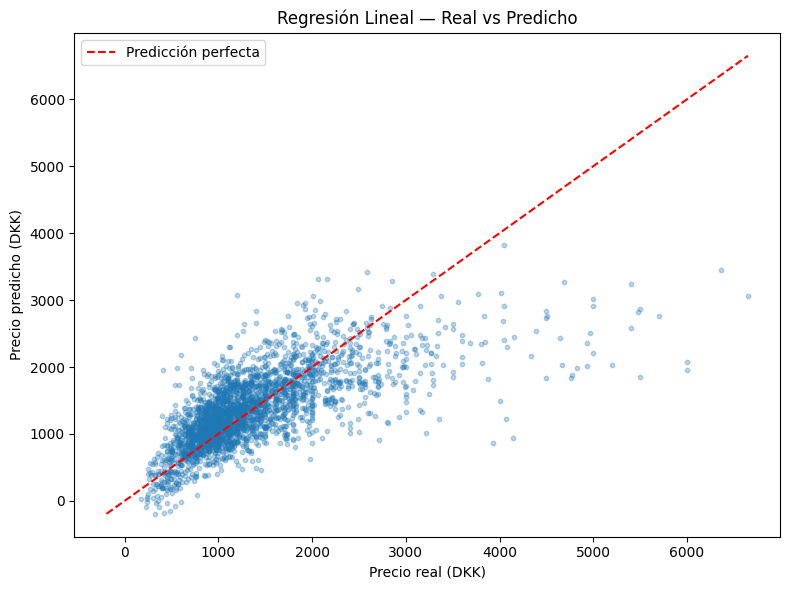

In [168]:
y_pred_test = modelo.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=10)

# Línea perfecta (donde pred = real)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')

plt.xlabel('Precio real (DKK)')
plt.ylabel('Precio predicho (DKK)')
plt.title('Regresión Lineal — Real vs Predicho')
plt.legend()
plt.tight_layout()
plt.show()

El R2 es similar en el entrenamiento y en el test, por lo que no hay overfitting. Explica en un 47% la variación del precio.

A pesar de todas las técnicas que se han empleado para tratar de mejorar el score, vemos en el gráfico que la nube de precios se mueve hacia la derecha de forma casi logarítmica y el modelo de regresión lineal no puede acompañar esa evolución.

# HGBOOST

Entrenamos un modelo base:

In [169]:
from xgboost import XGBRegressor

if USAR_MODELOS_CACHEADOS:
    modelo_xgb = joblib.load('modelos/xgboost_base.joblib')
    print("XGBoost base cargado desde disco")
else:
    modelo_xgb = XGBRegressor(random_state=42)
    modelo_xgb.fit(X_train, y_train)
    joblib.dump(modelo_xgb, 'modelos/xgboost_base.joblib')
    print("XGBoost base entrenado y guardado")

evaluar("TRAIN", y_train, modelo_xgb.predict(X_train))
evaluar("TEST",  y_test,  modelo_xgb.predict(X_test))

XGBoost base cargado desde disco

--- TRAIN ---
MAE:  164.92
RMSE: 228.17
R²:   0.9148

--- TEST ---
MAE:  343.26
RMSE: 519.46
R²:   0.5257


El modelo base muestra un overfitting muy claro 90% vs 52%. Es necesario ajustar los hiperparámetros.

Puedo usar RandomizedSearch para que busque la mejor combinación de hiperparámetros usando una muestra aleatoria (más rápido), uso k-fold como técnica para ir variando la porción que se toma para los tests.

In [170]:
from sklearn.model_selection import RandomizedSearchCV

if USAR_MODELOS_CACHEADOS:
    random_search = joblib.load('modelos/xgboost_search_v1.joblib')
    print("RandomizedSearchCV v1 cargado desde disco")
else:
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 1.0]
    }

    random_search = RandomizedSearchCV(
        estimator=XGBRegressor(random_state=42),
        param_distributions=param_grid,
        n_iter=30, cv=5, scoring='r2',
        random_state=42, n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    joblib.dump(random_search, 'modelos/xgboost_search_v1.joblib')
    print("RandomizedSearchCV v1 entrenado y guardado")

print(f"Mejores hiperparámetros: {random_search.best_params_}")
print(f"Mejor R² en CV: {random_search.best_score_:.4f}")

RandomizedSearchCV v1 cargado desde disco
Mejores hiperparámetros: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
Mejor R² en CV: 0.5520


Evaluo el mejor modelo:

In [171]:
mejor_modelo = random_search.best_estimator_

evaluar("TRAIN", y_train, mejor_modelo.predict(X_train))
evaluar("TEST",  y_test,  mejor_modelo.predict(X_test))


--- TRAIN ---
MAE:  252.44
RMSE: 367.30
R²:   0.7791

--- TEST ---
MAE:  324.07
RMSE: 493.50
R²:   0.5719


Veamos si se puede mejorar el overfitting, vamos a probar reduciendo un poco la profundidad de los árboles y agregando regularización L1 y L2

In [172]:
if USAR_MODELOS_CACHEADOS:
    random_search = joblib.load('modelos/xgboost_search_v2.joblib')
    print("RandomizedSearchCV v2 cargado desde disco")
else:
    param_grid = {
        'n_estimators': [200, 300],
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.05],
        'subsample': [0.7, 0.8],
        'reg_alpha': [0, 0.1, 1], #Regularizacion L1
        'reg_lambda': [1, 5, 10], #Regularizacion L2
        'min_child_weight': [1, 5, 10]
    }

    random_search = RandomizedSearchCV(
        estimator=XGBRegressor(random_state=42),
        param_distributions=param_grid,
        n_iter=30, cv=5, scoring='r2',
        random_state=42, n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    joblib.dump(random_search, 'modelos/xgboost_search_v2.joblib')
    print("RandomizedSearchCV v2 entrenado y guardado")

print(f"Mejores hiperparámetros: {random_search.best_params_}")
print(f"Mejor R² en CV: {random_search.best_score_:.4f}")

RandomizedSearchCV v2 cargado desde disco
Mejores hiperparámetros: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05}
Mejor R² en CV: 0.5538


In [173]:
mejor_modelo = random_search.best_estimator_

evaluar("TRAIN", y_train, mejor_modelo.predict(X_train))
evaluar("TEST",  y_test,  mejor_modelo.predict(X_test))


--- TRAIN ---
MAE:  260.11
RMSE: 391.42
R²:   0.7491

--- TEST ---
MAE:  321.92
RMSE: 491.03
R²:   0.5762


Aún queda overfitting, probaremos bajando un poco más la profundidad

In [174]:
if USAR_MODELOS_CACHEADOS:
    mejor_modelo = joblib.load('modelos/xgboost_optimizado.joblib')
    random_search = joblib.load('modelos/xgboost_search_v3.joblib')
    print("XGBoost optimizado cargado desde disco")
else:
    param_grid = {
        'n_estimators': [200, 300],
        'max_depth': [3],
        'learning_rate': [0.01, 0.05],
        'subsample': [0.7, 0.8],
        'reg_alpha': [0, 0.1, 1], #Regularizacion L1
        'reg_lambda': [1, 5, 10], #Regularizacion L2
        'min_child_weight': [1, 5, 10]
    }

    random_search = RandomizedSearchCV(
        estimator=XGBRegressor(random_state=42),
        param_distributions=param_grid,
        n_iter=30, cv=5, scoring='r2',
        random_state=42, n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    mejor_modelo = random_search.best_estimator_
    joblib.dump(mejor_modelo, 'modelos/xgboost_optimizado.joblib')
    joblib.dump(random_search, 'modelos/xgboost_search_v3.joblib')
    print("XGBoost optimizado entrenado y guardado")

print(f"Mejores hiperparámetros: {random_search.best_params_}")
print(f"Mejor R² en CV: {random_search.best_score_:.4f}")

XGBoost optimizado cargado desde disco
Mejores hiperparámetros: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05}
Mejor R² en CV: 0.5339


In [175]:
mejor_modelo = random_search.best_estimator_

evaluar("TRAIN", y_train, mejor_modelo.predict(X_train))
evaluar("TEST",  y_test,  mejor_modelo.predict(X_test))


--- TRAIN ---
MAE:  312.35
RMSE: 486.66
R²:   0.6122

--- TEST ---
MAE:  331.71
RMSE: 504.97
R²:   0.5518


El overfitting disminuyó en manera significativa a costo de un poco de precisión

Grafico cuales fueron las variables más importantes:

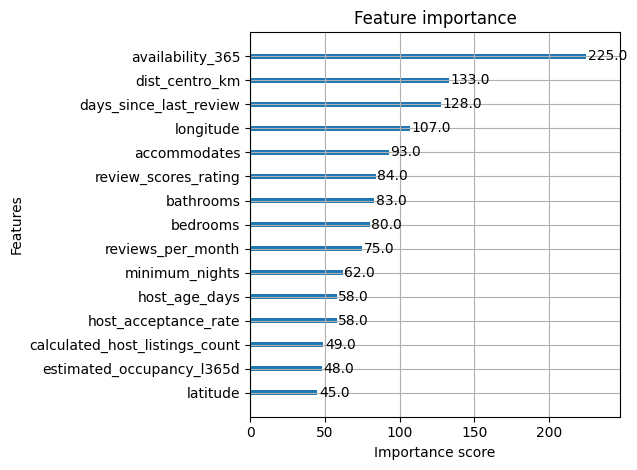

In [176]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(mejor_modelo, max_num_features=15)
plt.tight_layout()
plt.show()

El resultado es similar al de la regresión lineal, aunque en este modelo no se puede diferenciar si el efecto es positivo o negativo, en este caso el campo "dist_centro_km" es importante pero negativamente y este gráfico no lo refleja.

Graficamos como ajusta a los precios reales:

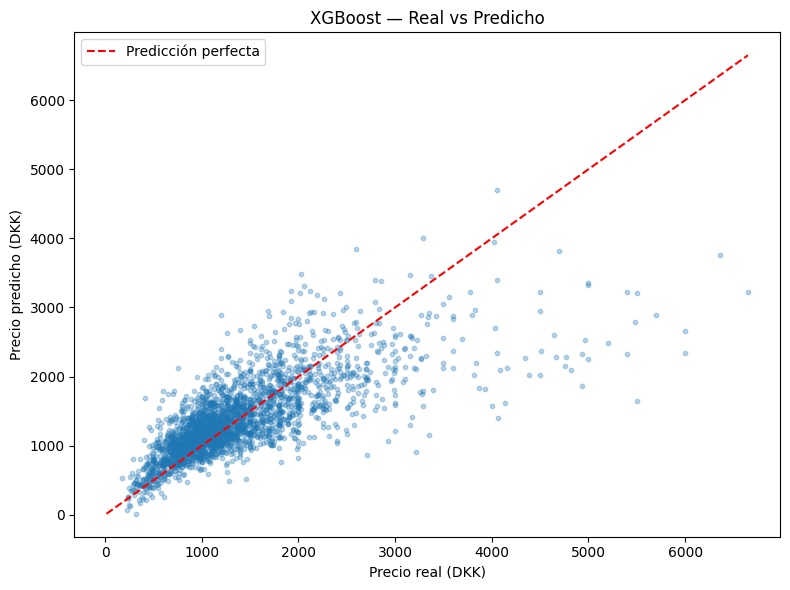

In [177]:
y_pred_test_xgb = mejor_modelo.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_xgb, alpha=0.3, s=10)

min_val = min(y_test.min(), y_pred_test_xgb.min())
max_val = max(y_test.max(), y_pred_test_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')

plt.xlabel('Precio real (DKK)')
plt.ylabel('Precio predicho (DKK)')
plt.title('XGBoost — Real vs Predicho')
plt.legend()
plt.tight_layout()
plt.show()

Vemos que tiene un problema similar a la regresión lineal donde no puede ajustar del todo la recta.

# Gradient boosting

Entrenamos el modelo usando gradient boosting y k-fold, elegimos este modelo ya que se supone que xgboost es una versión mejorada de él, por lo que lo corroboraremos. Evitamos ajustar los hiperparámetros porque es un modelo considerablemente más lento que xgboost.

In [178]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

if USAR_MODELOS_CACHEADOS:
    modelo_gb = joblib.load('modelos/gradient_boosting.joblib')
    scores_cv = joblib.load('modelos/gb_cv_scores.joblib')
    print("Gradient Boosting cargado desde disco")
else:
    modelo_gb = GradientBoostingRegressor(random_state=42)
    #k-fold
    scores_cv = cross_val_score(modelo_gb, X_train, y_train, cv=5, scoring='r2')
    modelo_gb.fit(X_train, y_train)
    joblib.dump(modelo_gb, 'modelos/gradient_boosting.joblib')
    joblib.dump(scores_cv, 'modelos/gb_cv_scores.joblib')
    print("Gradient Boosting entrenado y guardado")

print(f"R² promedio CV: {scores_cv.mean():.4f}")
print(f"Desvío:         {scores_cv.std():.4f}")
evaluar("TRAIN", y_train, modelo_gb.predict(X_train))
evaluar("TEST",  y_test,  modelo_gb.predict(X_test))

Gradient Boosting cargado desde disco
R² promedio CV: 0.5106
Desvío:         0.0175

--- TRAIN ---
MAE:  321.21
RMSE: 497.66
R²:   0.5945

--- TEST ---
MAE:  336.99
RMSE: 515.87
R²:   0.5322


Los resultados son muy buenos, un overfitting bastante bajo un R2 aceptable.

Graficaremos este último modelo:

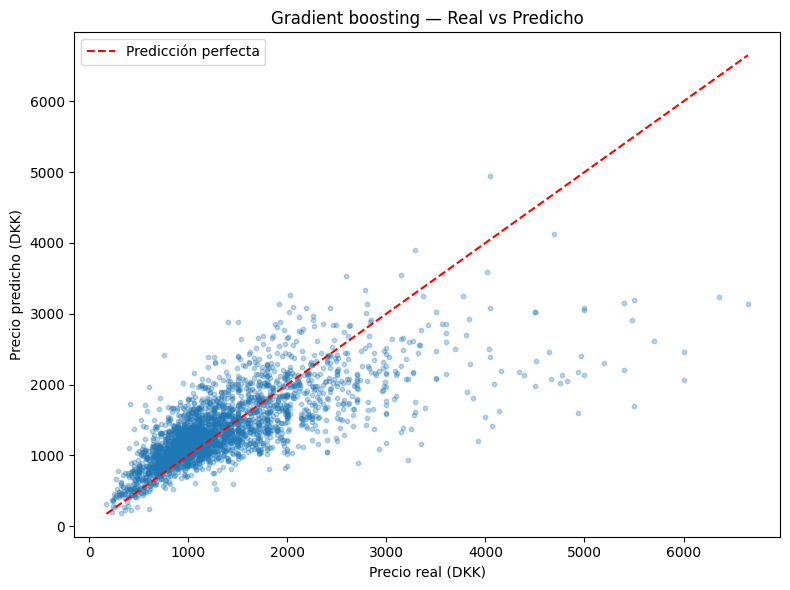

In [179]:
y_pred_test_xgb = modelo_gb.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_xgb, alpha=0.3, s=10)

min_val = min(y_test.min(), y_pred_test_xgb.min())
max_val = max(y_test.max(), y_pred_test_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')

plt.xlabel('Precio real (DKK)')
plt.ylabel('Precio predicho (DKK)')
plt.title('Gradient boosting — Real vs Predicho')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Comparación final

Los resultados de los 3 modelos son los siguientes:

| Modelo | R² test | MAE test | RMSE test | Overfitting (∆R²) |
| :--- | :---: | :---: | :---: | :---: |
| Regresión Lineal | 0.478 | 366 DKK | 545 DKK | ~0 |
| XGBoost | 0.552 | 332 DKK | 505 DKK | 0.060 |
| Gradient Boosting | 0.532 | 337 DKK | 516 DKK | 0.062 |

Graficamos los 3:

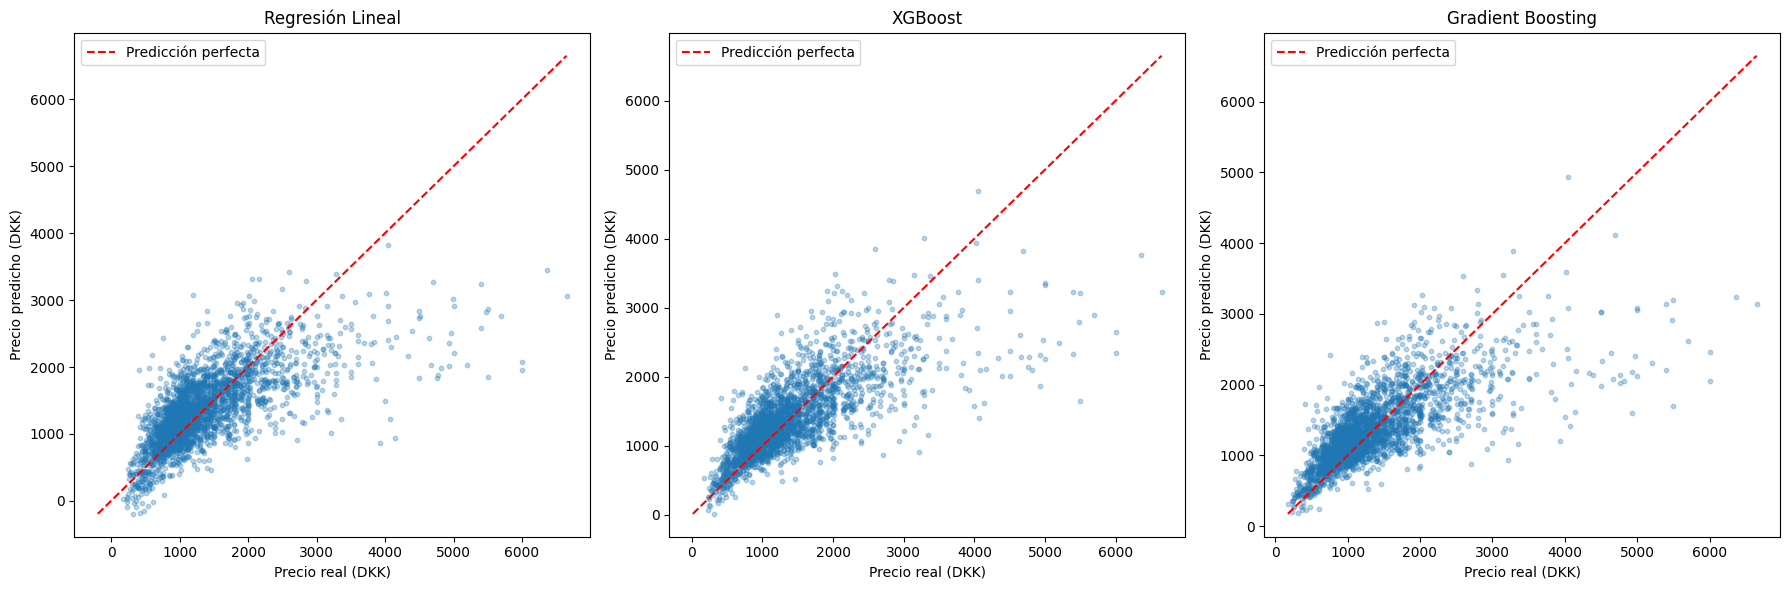

In [180]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

modelos = [
    (modelo, X_test_scaled, y_test, 'Regresión Lineal'),
    (mejor_modelo, X_test, y_test, 'XGBoost'),
    (modelo_gb, X_test, y_test, 'Gradient Boosting')
]

for ax, (m, X, y, titulo) in zip(axes, modelos):
    y_pred = m.predict(X)
    ax.scatter(y, y_pred, alpha=0.3, s=10)
    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')
    ax.set_xlabel('Precio real (DKK)')
    ax.set_ylabel('Precio predicho (DKK)')
    ax.set_title(titulo)
    ax.legend()

plt.tight_layout()
plt.show()

# Conclusión final

Para este problema en particular elegiríamos XGBoost (una versión mejorada de gradient boosting), ya que no solo es el que tiene un mejor R2, sino porque se adapta mejor a la naturaleza de este problema que tiene interacciones complejas y no lineales. La regresión lineal si bien casi no presenta overfitting, tiene limitaciones para capturas las relaciones no lineales entre las variables.